# BD2 -- Sesión 6 -- Cassandra

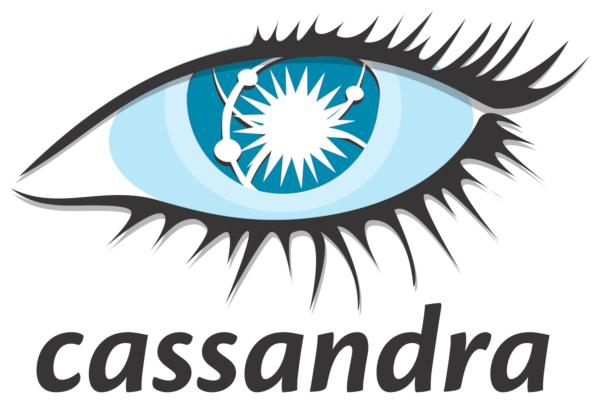

Esta hoja muestra cómo acceder a la base de datos Cassandra y también a conectar la salida con Jupyter.

Con Cassandra vamos a simular un modo semi-clúster con una sola máquina.

In [1]:
import sys

RunningInCOLAB: bool = "google.colab" in sys.modules

In [2]:
# Aparentemente han eliminado java de los paquetes instalados
if RunningInCOLAB:
    !sudo apt-get update && sudo apt-get install -y default-jdk-headless  --no-install-recommends

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,969 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:11 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,311 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/ma

In [3]:
if RunningInCOLAB:
    # Search for the first java interpreter. This code should work. If not, adjust JAVA_HOME manually.
    import os
    from pathlib import Path

    def find_java_home() -> str | None:
        p = Path("/usr/lib/jvm")
        (_, dirs, _) = next(os.walk(p))
        for d in dirs:
            inner_java: Path = p / d / "bin" / "java"
            if inner_java.is_file() and inner_java.stat().st_mode & 0o111:
                return str(p.joinpath(d).absolute())
        return None

    JAVA_HOME: str | None = os.getenv("JAVA_HOME", find_java_home())
    %env JAVA_HOME=$JAVA_HOME

env: JAVA_HOME=/usr/lib/jvm/java-1.17.0-openjdk-amd64


## Instalación de Apache Cassandra (sólo Google Colab)

Descargamos el ejecutable comprimido desde su página oficial. Sólo si estamos en Colab.

In [ ]:
if RunningInCOLAB:
    # Determinar qué versión 5.x.x de Cassandra es la más reciente.
    import re
    from re import Pattern
    from urllib.request import Request, urlopen

    from bs4 import BeautifulSoup

    version_re: Pattern = re.compile(r"^(5\.[0-9]+(\.[0-9]+)?)")
    req = Request("https://dlcdn.apache.org/cassandra/")
    html_page = urlopen(req)

    soup = BeautifulSoup(html_page)
    bigger5x: str = max(
        *[
            m.group(0)
            for m in [version_re.match(link.get_text()) for link in soup.find_all("a")]
            if m
        ],
        "5.0.0",
    )  # Base version 5.x.x
    %env CASSANDRA_VER=$bigger5x

Descarga de Cassandra y de su firma digital SHA256 para comprobar que el fichero es correcto. Si es correcto, se descomprime. Esto sólo se realiza en Google Colab.

In [ ]:
if RunningInCOLAB:
    import hashlib
    import os
    import tarfile
    import urllib.request
    from typing import cast

    # Descargar Cassandra y su firma digital SHA256
    cassandra_version: str = os.getenv("CASSANDRA_VER", "5.0.0")
    urllib.request.urlretrieve(
        f"https://dlcdn.apache.org/cassandra/{cassandra_version}/apache-cassandra-{cassandra_version}-bin.tar.gz",
        f"apache-cassandra-{cassandra_version}-bin.tar.gz",
    )
    urllib.request.urlretrieve(
        f"https://dlcdn.apache.org/cassandra/{cassandra_version}/apache-cassandra-{cassandra_version}-bin.tar.gz.sha256",
        f"apache-cassandra-{cassandra_version}-bin.tar.gz.sha256",
    )

    # Comprobar la firma digital SHA256
    sha256_hash = hashlib.sha256()
    with open(f"apache-cassandra-{cassandra_version}-bin.tar.gz", "rb") as f:
        # Read and update hash string value in blocks of 4K
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(cast(bytes, byte_block))
    with open(f"apache-cassandra-{cassandra_version}-bin.tar.gz.sha256") as f:
        expected_hash: str = f.read().split()[0]
    if sha256_hash.hexdigest() != expected_hash:
        raise ValueError("Downloaded Cassandra binary does not match the expected SHA256 hash.")

    # Descomprimir Cassandra
    with tarfile.open(f"apache-cassandra-{cassandra_version}-bin.tar.gz", "r:gz") as tar:
        tar.extractall()

Dependiendo de la versión de Java, hay que ejecutar Cassandra con un parámetro adicional.

In [ ]:
if RunningInCOLAB:
    javav = !javap -verbose java.lang.String | grep "major version" | cut -d ' ' -f 5
    cassandra_opts: str = ""
    if int(javav[0]) > 55:
        cassandra_opts = "-Djava.security.manager=allow"
    %env CASSANDRA_OPTS=$cassandra_opts

Hay que cambiar cuestiones de la configuracion de Cassandra para permitir *batches* más grandes:

In [ ]:
if RunningInCOLAB:
    import os
    import re

    config_file: str = f"apache-cassandra-{os.environ['CASSANDRA_VER']}/conf/cassandra.yaml"

    # Read the configuration file
    with open(config_file) as f:
        content: str = f.read()

    # Apply the same replacements as the sed command
    content = re.sub(r"(batch_size_warn_threshold:).*", r"\1 128KiB", content)
    content = re.sub(r"(batch_size_fail_threshold:).*", r"\1 1024KiB", content)

    # enable_materialized_views
    content = re.sub(r'(materialized_views_enabled:).*',r'\1 true', content)

    # Write back the modified content
    with open(config_file, "w") as f:
        f.write(content)

Arracamos la base de datos (el parámetro `-R` ejecuta el servidor en segundo plano y además permite ejecutarlo como `root`).

In [ ]:
if RunningInCOLAB:
    !(cd apache-cassandra-${CASSANDRA_VER}/ && sudo bin/cassandra -R ${CASSANDRA_OPTS})

Con el comando `nodetool status` podemos ver que nuestro cluster contiene un único datacenter, con un único host. Hacemos un bucle para esperar hasta que esté disponible, porque la inicialización lleva un tiempo.

In [ ]:
import os

CASSANDRA_HOST: str = "localhost" if RunningInCOLAB else os.getenv("DB_HOSTNAME", "localhost")
%env CASSANDRA_HOST=$CASSANDRA_HOST

In [ ]:
if RunningInCOLAB:
    !until apache-cassandra-${CASSANDRA_VER}/bin/nodetool -h ${CASSANDRA_HOST} status | grep '^UN '; do sleep 5; done
    !echo "Cassandra is up and running."

Si quisieramos abrir el shell de comandos de Cassandra para ejecutar instrucciones directamente sobre ella deberíamos ejecutar el siguiente comando.

*De todas formas, dejamos la celda comentada puesto que nuestro interés es acceder a la BD mediante Python*.

In [ ]:
#!apache-cassandra-${CASSANDRA_VER}/bin/cqlsh

## Acceso a Cassandra mediante Python

El *driver* de Cassandra para python nos permite ejecutar consultas CQL (https://docs.datastax.com/en/cql-oss/3.3/cql/cql_reference/cqlReferenceTOC.html) directamente desde Python. La función principal es `session.execute()` (https://docs.datastax.com/en/developer/python-driver/3.29/api/cassandra/cluster/index.html, https://docs.datastax.com/en/developer/python-driver/3.29/api/cassandra/cluster/index.html#cassandra.cluster.Session.execute), que ejecuta una consulta CQL y devuelve los resultados.

Los resultados se devuelven en un objeto de tipo `ResultSet` (https://docs.datastax.com/en/developer/python-driver/3.29/api/cassandra/cluster/index.html#cassandra.cluster.ResultSet), que se puede iterar para obtener las filas devueltas por la consulta. También tiene la opción de, si es un único resultado, usar `one()` para obtener la primera fila directamente. Y también se puede convertir a una lista con `all()`.

Cada una de las filas devueltas es un objeto similar a una tupla, donde se puede acceder a los valores de las columnas por su nombre o por su índice (`Row`).

Instalamos la librería `cassandra-driver` que nos dará acceso a nuestra instancia de Cassandra.

In [ ]:
%pip install cassandra-driver python-snappy more_itertools tenacity 'pandas[performance,plot,html,parquet]'

## Conexión al Cluster de Cassandra

Nos conectamos al cluster de Cassandra de forma inteligente, detectando automáticamente el tipo de configuración basándose en la variable de entorno `DB_HOSTNAME`:

### Configuraciones Soportadas:

1. **Local (Single Node)**:
   - `DB_HOSTNAME` no establecida, `127.0.0.1`, o `localhost`
   - Se conecta a un nodo único de Cassandra ejecutándose localmente

2. **Docker (Multi-Node)**:
   - `DB_HOSTNAME` = `cassandra1`
   - Se conecta a un cluster que puede ser de 1 o 2 nodos: `cassandra1` y `cassandra2` (dependiendo del docker-compose.yml que se use)
   - Sólo se pasa como *contact point* un nodo. El driver descubre la topología completa via *gossip*.

El código detecta automáticamente la configuración y establece los puntos de contacto apropiados para cada escenario.

In [ ]:
import os
import time

from cassandra.cluster import Cluster, Host, ResultSet, Session

db_hostname = os.getenv("DB_HOSTNAME", "localhost")
cluster = Cluster([db_hostname], port=9042, compression=True)

# Enter a connection loop to wait for the cluster to be ready
_session: Session | None = None
for _ in range(10):
    try:
        _session = cluster.connect()
        break
    except Exception as e:
        print(f"Error connecting to Cassandra cluster: {e}")
        time.sleep(5)

if _session is None:
    print("Failed to connect to Cassandra cluster.")
    # Handle the error as appropriate for your application
    raise

assert _session is not None, "Session should not be None after connection attempt"

# Establecer la variable de sesión. Será nuestra conexión a Cassandra.
session: Session = _session
session.default_timeout = 40

In [ ]:
from cassandra import (
    OperationTimedOut,
    ReadFailure,
    ReadTimeout,
    Unavailable,
    WriteFailure,
    WriteTimeout,
)
from tenacity import (
    retry,
    retry_if_exception_type,
    stop_after_attempt,
    wait_exponential,
)


@retry(
    retry=retry_if_exception_type((Unavailable, ReadTimeout, WriteTimeout, ReadFailure, WriteFailure, OperationTimedOut)),
    reraise=True,
    stop=stop_after_attempt(5),
    wait=wait_exponential(multiplier=1, min=1, max=8),
)
def execute_cassandra(session: Session, query, params=None) -> ResultSet:
    return session.execute(query, params)


# Ejecutar una primera consulta para verificar la conexión.
row = session.execute("SELECT release_version FROM system.local").one()
if row:
    print(f"Cassandra version: {row[0]}")

Listamos el conjunto de nodos:

In [ ]:
hosts: list[Host] = cluster.metadata.all_hosts() if cluster.metadata else []
nhosts: int = len(hosts)
nhosts, hosts

In [ ]:
local_query = "SELECT rpc_address FROM system.local"
for _ in cluster.metadata.all_hosts() if cluster.metadata else []:
    print(session.execute(local_query).one())

## Caso de uso avanzado: Trabajando con los datos de StackOverflow
### Descarga de datos

Descargamos los ficheros de *stackoverflow* para trabajar con ellos en Cassandra.

<details><summary><b>🗂️ Formato datos Stack Overflow (completo)</b> <span style="color: #007acc;">▶️ Haz click para ver el esquema y ejemplos</span></summary>

> Notas generales
- Formato: cada fichero es XML y suele distribuirse 7zipped.
- Codificación: UTF-8. Los campos de fecha siguen el formato ISO8601: "YYYY-MM-DDTHH:mm:ss.fff".
- Nulos: cuando un campo no aplica (p.ej., `ParentId` en preguntas), no aparece o viene vacío; en nuestros Parquet suele ser `null`.
- Identificadores: `Id` es clave primaria en cada entidad. Claves foráneas enlazan por `Id` entre ficheros.

---

:file_folder: <b>badges.xml</b> (insignias logradas por usuarios)
- UserId: Id del usuario que recibe la insignia. Ej: 420. Uso: FK a `users.Id`.
- Name: Nombre de la insignia. Ej: "Teacher". Uso: clasificar tipo de logro.
- Date: Fecha de concesión. Ej: "2008-09-15T08:55:03.923". Uso: series temporales.
- Class: Categoría (1=Gold, 2=Silver, 3=Bronze). Ej: 3. Uso: nivel de la insignia.
- TagBased: Si la insignia es específica de etiqueta. Ej: true. Uso: filtrar logros por etiquetas.

---

:file_folder: <b>comments.xml</b> (comentarios en publicaciones)
- Id: Identificador del comentario. Ej: 12345. Uso: PK.
- PostId: Publicación a la que comenta. Ej: 100234. Uso: FK a `posts.Id`.
- Score: Puntuación del comentario. Ej: 5. Uso: ordenar/filtrar relevancia.
- Text: Texto del comentario. Ej: "¿Puedes compartir el error exacto?". Uso: contenido.
- CreationDate: Fecha de creación. Ej: "2008-09-06T08:07:10.730". Uso: análisis temporal.
- UserId: Autor del comentario. Ej: 314159. Uso: FK a `users.Id`.
- UserDisplayName: Nombre mostrado si el usuario fue eliminado. Ej: "user123". Uso: se usa cuando `UserId` es nulo/ausente.
- ContentLicense: Licencia del contenido. Ej: "CC BY-SA 4.0". Uso: cumplimiento/licencias.

---

:file_folder: <b>posts.xml</b> (preguntas y respuestas)
- Id: Identificador de la publicación. Ej: 98765. Uso: PK.
- PostTypeId: Tipo (1=Pregunta, 2=Respuesta). Ej: 1. Uso: rutas de procesamiento/particionado.
- ParentId: Id de la pregunta padre si es respuesta. Ej: 1234. Uso: FK a `posts.Id` (solo si `PostTypeId=2`).
- AcceptedAnswerId: Id de la respuesta aceptada (solo en preguntas). Ej: 4567. Uso: FK a `posts.Id` para marcar aceptadas.
- CreationDate: Fecha de creación. Ej: "2010-02-15T10:21:34.120". Uso: análisis temporal.
- Score: Votos netos (upvotes-downvotes). Ej: 42. Uso: ranking/calidad.
- ViewCount: Nº de vistas (solo preguntas). Ej: 12345. Uso: popularidad.
- Body: HTML/Markdown del cuerpo. Ej: "<p>¿Cómo...?</p>". Uso: contenido/NLP.
- OwnerUserId: Autor. Ej: 271828. Uso: FK a `users.Id`.
- OwnerDisplayName: Nombre mostrado si el autor fue eliminado. Ej: "John Doe". Uso: se usa cuando `OwnerUserId` es nulo (usuario eliminado o anónimo).
- LastEditorUserId: Último usuario que editó. Ej: 314159. Uso: FK a `users.Id`.
- LastEditorDisplayName: Nombre si el editor fue eliminado. Ej: "Community". Uso: solo cuando `LastEditorUserId` es nulo.
- LastEditDate: Fecha de última edición. Ej: "2009-03-05T22:28:34.823". Uso: auditoría.
- LastActivityDate: Última actividad (edición, comentario, etc.). Ej: "2009-03-11T12:51:01.480". Uso: ordenación por actividad reciente.
- CommunityOwnedDate: Fecha desde la que es de la comunidad. Ej: "2009-03-11T12:51:01.480". Uso: gobernanza.
- ClosedDate: Fecha de cierre (si procede). Ej: "2012-01-01T12:00:00.000". Uso: moderación.
- Title: Título de la pregunta. Ej: "¿Cómo unir listas en Python?". Uso: metadata/búsqueda.
- Tags: Lista de etiquetas en formato XML/HTML: "<python><list><merge>". Uso: clasificación por tema.
- AnswerCount: Nº de respuestas (en preguntas). Ej: 5. Uso: engagement.
- CommentCount: Nº de comentarios. Ej: 3. Uso: actividad.
- FavoriteCount: Favoritos marcados (legacy). Ej: 10. Uso: popularidad histórica.
- ContentLicense: Licencia. Ej: "CC BY-SA 4.0". Uso: cumplimiento.

---

:file_folder: <b>posthistory.xml</b> (historial detallado de cambios)
- Id: PK del evento de historial. Ej: 5555.
- PostHistoryTypeId: Tipo de cambio. Uso: clasifica el evento. Ejemplos:
  - 1: Initial Title – primer título de la pregunta.
  - 2: Initial Body – primer cuerpo en crudo.
  - 3: Initial Tags – primeras etiquetas.
  - 4: Edit Title – cambio de título.
  - 5: Edit Body – cambio de cuerpo (markdown crudo).
  - 6: Edit Tags – cambio de etiquetas.
  - 7/8/9: Rollback Title/Body/Tags – revertidos.
  - 10: Post Closed – cierre por votos.
  - 11: Post Reopened – reapertura.
  - 12/13: Post Deleted/Undeleted – borrado/restaurado.
  - 14/15: Post Locked/Unlocked – bloqueado/desbloqueado.
  - 16: Community Owned – pasa a comunidad.
  - 17: Post Migrated – migración (origen/destino).
  - 18: Question Merged – fusión de preguntas.
  - 19/20: Question Protected/Unprotected – protegido/desprotegido.
  - 21: Post Disassociated – se elimina el OwnerUserId.
  - 22: Question Unmerged – deshace fusión.
- PostId: Publicación afectada. Ej: 98765. Uso: FK a `posts.Id`.
- RevisionGUID: Agrupa múltiples registros de un mismo acto. Ej: "3E5B...". Uso: correlación.
- CreationDate: Fecha del evento. Ej: "2009-03-05T22:28:34.823".
- UserId: Usuario que realiza el cambio. Ej: 271828. Uso: FK a `users.Id`.
- UserDisplayName: Si el usuario fue eliminado. Ej: "user123". Uso: cuando `UserId` nulo.
- Comment: Comentario del editor. Ej: "typo fix". Uso: auditoría.
- Text: Valor crudo nuevo asociado al cambio. Ej: nuevo markdown o JSON.
  - Para tipos 10–15: JSON con usuarios que han votado esa acción de moderación.
  - Para tipo 17: Detalles de migración: "from <url>" o "to <url>".
- CloseReasonId: Motivo de cierre (histórico). Ejemplos:
  - 1: Exact Duplicate – duplicada de otra.
  - 2: off-topic – fuera de tema.
  - 3: subjective – demasiado subjetiva.
  - 4: not a real question – no es una pregunta real.
  - 7: too localized – demasiado localizada.

---

:file_folder: <b>postlinks.xml</b> (enlaces entre publicaciones)
- Id: PK del enlace. Ej: 2222.
- CreationDate: Fecha del enlace. Ej: "2011-05-05T10:00:00.000".
- PostId: Publicación origen. Ej: 1000. Uso: FK a `posts.Id`.
- RelatedPostId: Publicación destino. Ej: 1001. Uso: FK a `posts.Id`.
- PostLinkTypeId: Tipo de relación. Uso: grafo entre posts.
  - 1: Linked – relacionados.
  - 3: Duplicate – duplicados.

---

:file_folder: <b>users.xml</b> (usuarios)
- Id: PK del usuario. Ej: 271828.
- AccountId: Id de cuenta en la red Stack Exchange. Ej: 123456. Uso: consolidación multi-sitio.
- Reputation: Reputación. Ej: 15234. Uso: privilegios/ordenación.
- CreationDate: Alta del usuario. Ej: "2008-07-31T21:42:52.667".
- DisplayName: Nombre mostrado. Ej: "Jane Doe". Uso: UI.
- EmailHash: Hash MD5 de email (legacy). Ej: "fcea920f...". Uso: avatar histórico.
- LastAccessDate: Último acceso. Ej: "2020-04-01T12:00:00.000". Uso: actividad.
- WebsiteUrl: Web personal. Ej: "https://janedoe.dev".
- Location: Ubicación libre. Ej: "Madrid, ES".
- Age: Edad (cuando se compartía). Ej: 32.
- AboutMe: BIO en HTML/Markdown. Ej: "<p>Desarrollo datos...</p>".
- Views: Visitas al perfil. Ej: 1234.
- UpVotes: Upvotes emitidos por el usuario. Ej: 500.
- DownVotes: Downvotes emitidos. Ej: 20.
- ProfileImageUrl: Avatar. Ej: "https://.../image.png".

---

:file_folder: <b>votes.xml</b> (votos a publicaciones)
- Id: PK del voto. Ej: 7777.
- PostId: Publicación votada. Ej: 98765. Uso: FK a `posts.Id`.
- VoteTypeId: Tipo de voto/acción. Uso: métricas de calidad/moderación.
  - 1: AcceptedByOriginator – el autor de la pregunta acepta una respuesta (equivale a `AcceptedAnswerId`).
  - 2: UpMod – upvote.
  - 3: DownMod – downvote.
  - 4: Offensive – ofensivo (legacy).
  - 5: Favorite – marcado como favorito (legacy); si `VoteTypeId=5`, `UserId` se rellena.
  - 6: Close – voto de cierre.
  - 7: Reopen – voto de reapertura.
  - 8: BountyStart – inicio de recompensa.
  - 9: BountyClose – cierre de recompensa; si `VoteTypeId=9`, `BountyAmount` se rellena.
  - 10: Deletion – voto de borrado.
  - 11: Undeletion – voto de restauración.
  - 12: Spam – marcado como spam.
  - 13: InformModerator – informar a moderación.
- CreationDate: Fecha del voto. Ej: "2015-06-10T09:30:00.000".
- UserId: Usuario que vota (solo para algunos tipos como 5). Ej: 54321. Uso: FK a `users.Id`.
- BountyAmount: Cantidad de recompensa (solo tipo 9). Ej: 100.

---

:file_folder: <b>tags.xml</b> (etiquetas del sitio)
- Id: PK de la etiqueta. Ej: 42.
- TagName: Nombre de la etiqueta. Ej: "python". Uso: clasificación temática.
- Count: Nº de usos en preguntas. Ej: 150234. Uso: popularidad.
- ExcerptPostId: Id del post con el extracto de la wiki de etiqueta. Ej: 123. Uso: FK a `posts.Id`.
- WikiPostId: Id del post con el artículo de la wiki de etiqueta. Ej: 124. Uso: FK a `posts.Id`.

</details>

In [ ]:
import pandas as pd
from pandas import DataFrame

In [ ]:
from asyncio import Queue


def load_dataframe(parquetfile: str, logqueue: Queue[str] | None = None) -> DataFrame:
    parquet_base_url: str = (
        "https://github.com/dsevilla/bd2-data/releases/download/parquet-files-25-26/"
    )
    try:
        df: DataFrame = pd.read_parquet(f"{parquet_base_url}/{parquetfile}")
        logqueue.put_nowait(f"Loaded {len(df)} rows from dataframe.") if logqueue else None

        # df.set_index('Id', inplace=True)
        # Cassandra tiene problemas con el tipo NaT, así que lo sustituimos por None
        return df.replace({pd.NaT: None})
    except Exception as e:
        logqueue.put_nowait(f"Error loading Dataframe: {e}.") if logqueue else None
        raise

Vamos a poner a descargar en paralelo todos los ficheros parquet. Conforme los vayamos necesitando los «esperaremos» con `await`. (Para acelerar el proceso no cargamos comentarios ni votos).

In [ ]:
from asyncio import create_task, to_thread

df_posts, df_users, df_tags = (  # , df_comments, df_votes = (
    create_task(to_thread(load_dataframe, "Posts.parquet")),
    create_task(to_thread(load_dataframe, "Users.parquet")),
    create_task(to_thread(load_dataframe, "Tags.parquet")),
    # create_task(to_thread(load_dataframe, "Comments.parquet")),
    # create_task(to_thread(load_dataframe, "Votes.parquet")),
)

### Creación de espacios de nombres y tablas

Vamos a crear ahora un `keyspace` llamado `stackoverflow` que vamos a usar posteriormente para definir las tablas necesarias. Un *keyspace* en Cassandra es similar a una base de datos en otros sistemas de gestión de bases de datos, ofrece un espacio de separación de nombres donde se pueden crear nuevas tablas. Los *keyspaces* también permiten definir opciones de replicación y otras configuraciones a nivel de espacio de nombres, que no veremos.

In [ ]:
from cassandra.cluster import ResultSet

resultado: ResultSet = execute_cassandra(session,
    """
    CREATE KEYSPACE IF NOT EXISTS stackoverflow
    WITH replication = {'class': 'SimpleStrategy', 'replication_factor': %d}
"""
    % (nhosts)
)

print(resultado.one())

Se utiliza ese *keyspace* a partir de ahora.

In [ ]:
session.set_keyspace("stackoverflow")

Construimos una función para generar los comandos CQL `CREATE TABLE` a partir de los esquemas que definimos anteriormente. Modificaremos esos esquemas para que se ajusten a las necesidades de Cassandra.

Como Cassandra tiene esquema, hay que definir las tablas antes de insertar los datos. Usamos la información que hay disponible en los esquemas PyArrow que generamos antes para crear las tablas con los tipos de datos adecuados. Además, hay que elegir una clave primaria para cada tabla, que es un requisito en Cassandra. Los campos de la clave se pasan como parámetros a la función `cassandra_create_table_from_pyarrow()`.

In [ ]:
from collections import OrderedDict

import pyarrow as pa

# Maps Arrow type ids (pa.DataType.id) to Cassandra CQL type names.
# Uses O(1) dict lookup instead of linear predicate search.
ARROW_TO_CASSANDRA_TYPE: dict[int, str] = {
    pa.string().id:            "text",
    pa.large_string().id:      "text",
    pa.int32().id:             "int",
    pa.int64().id:             "bigint",
    pa.int16().id:             "smallint",
    pa.int8().id:              "tinyint",
    pa.uint32().id:            "bigint",
    pa.uint64().id:            "bigint",
    pa.uint16().id:            "int",
    pa.uint8().id:             "smallint",
    pa.timestamp("ms").id:     "timestamp",
    pa.date32().id:            "date",
    pa.date64().id:            "date",
    pa.float64().id:           "double",
    pa.float32().id:           "float",
    pa.float16().id:           "float",
    pa.bool_().id:             "boolean",
    pa.binary().id:            "blob",
    pa.large_binary().id:      "blob",
    pa.decimal128(1).id:       "decimal",
    pa.time32("ms").id:        "time",
    pa.time64("us").id:        "time",
}


def _map_arrow_type_to_cassandra(t: pa.DataType) -> str:
    return ARROW_TO_CASSANDRA_TYPE.get(t.id, "text")


def cassandra_create_table_from_pyarrow(
    schema: pa.Schema,
    table_name: str,
    key_form: str | list[str | list[str]] | None = None,
    exclude_fields: list[str] | None = None,
    clustering_order: dict[str, str] | None = None,
    keyspace: str | None = None,
) -> str:
    """
    Generate a CREATE TABLE CQL statement from a PyArrow schema.

    Args:
        schema: pyarrow.Schema instance.
        table_name: target table name (no keyspace).
        key_form: list of lists of column names. First inner list is partition key columns,
                  remaining inner lists are flattened and used as clustering keys in order.
                  Example: [['user_id'], 'bucket', 'created_at']
        exclude_fields: list of field names to skip.
        clustering_order: optional dict mapping clustering column -> "ASC" or "DESC".
        keyspace: optional keyspace name to prefix table.

    Returns:
        cql_create_statement: str
    """
    exclude: set[str] = set(exclude_fields or [])
    columns: OrderedDict[str, str] = OrderedDict()
    for fld in schema:
        if fld.name in exclude:
            continue
        cass_t: str = _map_arrow_type_to_cassandra(fld.type)
        columns[fld.name] = cass_t

    if not columns:
        raise ValueError("No columns left after applying exclude_fields.")

    # Build PRIMARY KEY
    if key_form:
        if not isinstance(key_form, (str, list)) or not all(
            isinstance(k, (str, list)) for k in key_form
        ):
            raise ValueError("Invalid key_form format.")

        match key_form:
            case str():  # "key"
                partition_cols: list[str] = [key_form]
                clustering_cols: list[str] = []
            case list():  # ["<key>", "<clustering>"] or [["<key1>", "<key2>", ...], "clustering"]
                match key_form[0]:
                    case list():
                        partition_cols = key_form[0]
                    case str():
                        partition_cols = [key_form[0]]
                clustering_cols: list[str] = key_form[1:]  # type: ignore
    else:
        field_names: list[str] = [f.name for f in schema if f.name not in exclude]
        partition_cols = [field_names[0]]
        clustering_cols = field_names[1:]

    for col in partition_cols + clustering_cols:
        if col not in columns:
            raise ValueError(f"Primary key column '{col}' not found in schema (or was excluded).")

    cols_cql_lines: list[str] = [f"  {name} {typ}" for name, typ in columns.items()]
    cols_cql_str: str = ",\n".join(cols_cql_lines)

    if len(partition_cols) == 1:
        pk_left: str = partition_cols[0]
    else:
        pk_left = "(" + ", ".join(partition_cols) + ")"
    pk_rest: str = ", ".join(clustering_cols) if clustering_cols else ""
    pk_clause: str = f"PRIMARY KEY ({pk_left}" + ((", " + pk_rest) if pk_rest else "") + ")"

    clustering_clause = ""
    if clustering_cols and clustering_order:
        orders: list[str] = []
        for c in clustering_cols:
            ordv: str | None = clustering_order.get(c)
            if ordv:
                ordv_upper = ordv.upper()
                if ordv_upper not in ("ASC", "DESC"):
                    raise ValueError("clustering_order values must be 'ASC' or 'DESC'")
                orders.append(f"{c} {ordv_upper}")
        if orders:
            clustering_clause: str = " \nAND CLUSTERING ORDER BY (" + ", ".join(orders) + ")"

    ks_prefix: str = f"{keyspace}." if keyspace else ""
    create: str = (
        f"CREATE TABLE IF NOT EXISTS {ks_prefix}{table_name} (\n{cols_cql_str},\n  {pk_clause}\n)"
        + " WITH compression = {'class': 'LZ4Compressor'} "
        + f"{clustering_clause};"
    )
    return create


# Minimal example


def print_example_cql_schema() -> None:
    schema: pa.Schema = pa.schema(
        [
            pa.field("user_id", pa.string()),
            pa.field("post_id", pa.string()),
            pa.field("created_at", pa.timestamp("ms")),
            pa.field("title", pa.string()),
            pa.field("score", pa.int32()),
            pa.field("tags", pa.list_(pa.string())),
        ]
    )

    cql: str = cassandra_create_table_from_pyarrow(
        schema,
        table_name="posts_by_user",
        key_form=[["user_id", "score"], "created_at"],
        exclude_fields=["body"],  # if present in schema
        clustering_order={"created_at": "DESC"},
        keyspace="stackoverflow",
    )
    print(cql)

In [ ]:
print_example_cql_schema()

#### Descarga y carga de esquemas

A continuación, antes de definir las tablas, vamos a descargar los esquemas de los datos para usarlos al crear las tablas.


In [ ]:
import io

import pyarrow as pa
import requests
from pyarrow import Schema


def read_remote_parquet_schema(url: str) -> Schema:
    """
    Downloads a remote Parquet file and returns its PyArrow schema.
    Args:
        url (str): The URL to the Parquet file.
    Returns:
        pyarrow.Schema: The schema of the Parquet file.
    """
    response: requests.Response = requests.get(url)
    response.raise_for_status()
    buffer = io.BytesIO(response.content)
    return pa.ipc.read_schema(buffer)

In [ ]:
from asyncio import Task, create_task, gather, to_thread
from collections.abc import Iterator

# Start async tasks to fetch schemas in parallel
BASE_URL: str = "https://github.com/dsevilla/bd2-data/raw/refs/heads/main/es.stackoverflow/parquet"

schema_files: list[str] = ["Posts.pb", "Users.pb", "Tags.pb", "Comments.pb", "Votes.pb"]
tasks: Iterator[Task[Schema]] = (
    create_task(to_thread(lambda url=url: read_remote_parquet_schema(f"{BASE_URL}/{url}")))
    for url in schema_files
)
(posts_schema, users_schema, tags_schema, comments_schema, votes_schema) = await gather(*tasks)

#### Tabla `Tags`

Vamos a crear la tabla `Tags`. La clave primaria es el `Id` de la etiqueta. La consulta se hace por `Id`, y también por `TagName`. Veremos cómo crear un índice adicional.

In [ ]:
tags_cql_create: str = cassandra_create_table_from_pyarrow(
    tags_schema,
    table_name="Tags",
    key_form=["Id"],
    exclude_fields=None,
    clustering_order=None,
    keyspace="stackoverflow",
)
print(tags_cql_create)

In [ ]:
execute_cassandra(session, tags_cql_create)

In [ ]:
def cassandra_insert_template(
    schema: pa.Schema,
    table_name: str,
    exclude_fields: set[str] | None = None,
    keyspace: str | None = None,
) -> str:
    """
    Construye una plantilla CQL de INSERT para Cassandra (placeholders posicionales '?') a partir
    de un esquema PyArrow.

    Devuelve insert_cql: str, donde:
      - insert_cql es, por ejemplo, "INSERT INTO ks.table (c1,c2) VALUES (?,?);"

    Notas:
      - Las columnas se toman en el orden definido por el esquema.
      - Los campos indicados en exclude_fields se omiten.
      - No realiza mapeo de tipos ni prepara la sentencia contra un clúster.
    """
    exclude: set[str] = exclude_fields or set()
    cols: list[str] = list(filter(lambda n: n not in exclude, map(lambda f: f.name, schema)))

    if not cols:
        raise ValueError("No columns remain after applying exclude_fields.")

    ks_prefix: str = f"{keyspace}." if keyspace else ""
    col_list: str = ", ".join(cols)
    placeholders: str = ", ".join("?" for _ in cols)
    cql: str = f"INSERT INTO {ks_prefix}{table_name} ({col_list}) VALUES ({placeholders});"
    return cql

#### Más sobre consultas, *statements* preparados

 Ya hemos visto que las consultas se pueden enviar directamente en texto, pero es recomendable utilizar *statements* preparados para mejorar el rendimiento y la seguridad. En Cassandra, los *statements* preparados se crean con `session.prepare()`, que devuelve un objeto `PreparedStatement`. Luego, para ejecutar el *statement* preparado, se utiliza `session.execute(prepared_statement, parameters)`, donde `parameters` es una tupla con los valores a sustituir en la consulta. El uso de *statements* preparados permite a Cassandra optimizar la ejecución de las consultas y evitar inyecciones CQL.

Cassandra también ofrece una función que realiza muchas consultas (en este caso inserciones) en paralelo, llamada `execute_concurrent()`. Esta función recibe una lista de tuplas con los *statements* preparados y sus parámetros, y ejecuta todas las consultas de forma concurrente, devolviendo una lista de resultados. En este caso usaremos `execute_concurrent_with_args()`, que es una variante que permite pasar una lista de conjuntos de parámetros. Esto nos permitirá insertar todos los lementos de un DataFrame de Pandas de forma eficiente.

En el código de abajo se utiliza la constante `UNSET_VALUE`, ofrecida por el driver de Cassandra, para indicar que un valor no se ha establecido. Esto es útil para omitir columnas que no queremos insertar o actualizar, y dejar que Cassandra use su valor por defecto o lo deje como `null`. Esto evita la creación de "celdas vacías", o _tombstones_, que pueden afectar al rendimiento de las consultas. Los _tombstones_ son marcadores que Cassandra utiliza para indicar que una celda ha sido eliminada o no tiene valor, y pueden ralentizar las consultas si hay demasiados. Con el uso de `UNSET_VALUE`, podemos evitar crear _tombstones_ innecesarios y mejorar el rendimiento de nuestras tablas.

In [ ]:
from cassandra import ConsistencyLevel
from cassandra.concurrent import execute_concurrent_with_args
from cassandra.query import UNSET_VALUE, PreparedStatement
from more_itertools import consume


def dataframe_to_cassandra(df: DataFrame, statement: PreparedStatement, session: Session) -> None:
    """
    Carga un array de datos en una tabla de Cassandra.
    """
    statement.consistency_level = ConsistencyLevel.ONE # Al menos uno responde
    statement.is_idempotent = True # Es idempotente porque son todos INSERT
    consume(
        execute_concurrent_with_args(
            session,
            statement,
            (tuple(UNSET_VALUE if pd.isna(x) else x for x in row)
               for row in df.itertuples(index=False, name=None)),
            concurrency=50,
            results_generator=True,
        ),
    )  # consumir el generador para forzar la ejecución


def background_import_df(
    df: DataFrame, statement: PreparedStatement, session: Session
) -> Task[None]:
    return create_task(to_thread(dataframe_to_cassandra, df, statement, session))

Se hace la inserción de los datos en la tabla `Tags`. Se podría hacer con `session.execute()` en un bucle, pero aquí se muestra cómo hacerlo con una llamada que lo importa en segundo plano, aunque después esperemos a que termine. Para las tablas más grandes, sí que será interesante que se haga en segundo plano.

In [ ]:
future_tags: Task[None] = background_import_df(
    await df_tags,
    session.prepare(cassandra_insert_template(tags_schema, "stackoverflow.Tags")),
    session,
)

In [ ]:
import asyncio

try:
    await asyncio.wait_for(future_tags, timeout=300)
except asyncio.TimeoutError:
    print("Timeout waiting for tags import to complete.")
    raise

print("Tags imported.")

Y veamos una consulta de selección sencilla.

In [ ]:
tags_result: ResultSet = execute_cassandra(session,
    """
    SELECT Id, TagName, Count
    FROM stackoverflow.Tags
    WHERE Id IN (1,2,3,4,5,6,7,8,9,10)
"""
)

# Almacenamos un tag_name para más adelante
tag_name_ejemplo = None

for row in tags_result:
    print(row.id, row.tagname, row.count)
    if tag_name_ejemplo is None:
      tag_name_ejemplo = row.tagname
    print("...")

In [ ]:
# Liberar memoria
del df_tags

#### Tablas `Questions` y `Answers`

A continuación vamos a crear las tablas `Questions` y `Answers`. ¿Por qué dos tablas cuando podríamos tener solo una?

El funcionamiento de Cassandra es diferente al de un SQL tradicional. Aunque el CQL es similar a SQL, tiene unas restricciones, como por ejemplo, que no puede utilizar funciones de agregación (`MAX`, `AVG`, etc.) ni `JOIN`s. Por eso, en este caso tomamos esta decisión. La explicaremos mejor después.

En la tabla `Questions` vamos a almacenar las preguntas y en la tabla `Answers` las respuestas. La relación entre ambas tablas es de uno a muchos, es decir, una pregunta puede tener muchas respuestas, pero una respuesta solo puede pertenecer a una pregunta.

Por lo tanto, la clave primaria de la tabla `Answers` será su question id. En la tabla `Questions` solo habrá un campo que será el su question id (`Id`). Además vamos a ordenar dichas preguntas por su fecha de creacion estableciendo el campo `CreationDate` como clave de clustering.

In [ ]:
questions_create_cql: str = cassandra_create_table_from_pyarrow(
    posts_schema,
    table_name="Questions",
    key_form=["Id", "CreationDate"],
    exclude_fields=["PostTypeId", "ParentId"],
    clustering_order={"CreationDate": "ASC"},
    keyspace="stackoverflow",
)
print(questions_create_cql)

Con `session.execute()` ejecutamos los comandos CQL para crear la tabla. Pero para evitar problemas de acceso a los hosts, usamos la función `execute_cassandra()` para que si hay un error temporal, se vuelva a intentar la consulta.

In [ ]:
execute_cassandra(session, questions_create_cql)

In [ ]:
from pandas import Series

questions_excluded_fields: set[str] = {
    "PostTypeId",
    "ParentId",
}


def questions_df(df_posts: DataFrame) -> DataFrame:
    # Filtrar las preguntas (PostTypeId == 1)
    mask: Series[bool] = df_posts["PostTypeId"].eq(1)
    return df_posts[mask].drop(columns=questions_excluded_fields)


def insert_questions_stmt(session: Session, table: str) -> PreparedStatement:
    return session.prepare(
        cassandra_insert_template(posts_schema, table, exclude_fields=questions_excluded_fields)
    )

In [ ]:
# Background import of questions
future_questions: Task[None] = background_import_df(
    questions_df(await df_posts),
    insert_questions_stmt(session, "stackoverflow.Questions"),
    session,
)

In [ ]:
# Done?
future_questions.done()

Vamos ahora a crear la tabla de respuestas (`Answers`). En este caso, la clave primaria es el `ParentId` (la pregunta a la que hace referencia). Además, establecemos el campo `CreationDate` como clave de clustering.

Haciendo la clave de partición dependiente del ID de la pregunta hacemos que todas las respuestas estén juntas en la misma *wide column*, acelerando las consultas.

In [ ]:
answers_cql_create: str = cassandra_create_table_from_pyarrow(
    posts_schema,
    table_name="Answers",
    key_form=["ParentId", "CreationDate"],
    exclude_fields=["AcceptedAnswerId", "AnswerCount", "ClosedDate", "PostTypeId", "Tags", "Title"],
    clustering_order={"CreationDate": "ASC"},
    keyspace="stackoverflow",
)
print(answers_cql_create)

In [ ]:
execute_cassandra(session,answers_cql_create)

Al igual que antes, usamos una tarea para hacer la inserción en segundo plano.

In [ ]:
def answers_df(df_posts: DataFrame) -> DataFrame:
    # Filtrar las respuestas (PostTypeId == 2)
    return df_posts[df_posts["PostTypeId"].eq(2)].drop(
        columns=["AcceptedAnswerId", "AnswerCount", "ClosedDate", "PostTypeId", "Tags", "Title"]
    )


def answers_insert_stmt(session: Session, table: str) -> PreparedStatement:
    return session.prepare(
        cassandra_insert_template(
            posts_schema,
            table,
            exclude_fields={
                "AcceptedAnswerId",
                "AnswerCount",
                "ClosedDate",
                "PostTypeId",
                "Tags",
                "Title",
            },
        )
    )


future_answers: Task[None] = background_import_df(
    answers_df(await df_posts),
    answers_insert_stmt(session, "stackoverflow.Answers"),
    session,
)

In [ ]:
future_answers.done()

#### Tabla `Users`

Vamos a crear la tabla `Users`. En este caso, la clave primaria es el `Id` del usuario. La consulta se hace por `Id`, por lo que no es necesario crear un índice adicional.


In [ ]:
users_cql_create: str = cassandra_create_table_from_pyarrow(
    users_schema,
    table_name="Users",
    key_form=["Id"],
    exclude_fields=None,
    clustering_order=None,
    keyspace="stackoverflow",
)
print(users_cql_create)

In [ ]:
execute_cassandra(session,users_cql_create)

In [ ]:
future_users: Task[None] = background_import_df(
    await df_users,
    session.prepare(cassandra_insert_template(users_schema, "stackoverflow.Users")),
    session,
)

In [ ]:
future_users.done()

In [ ]:
# wait for the task future_questions, future_answers, and future_users, but only 300 seconds
import asyncio

try:
    await asyncio.wait(
        (future_questions, future_answers, future_users),
        timeout=300,
        return_when=asyncio.ALL_COMPLETED,
    )
except asyncio.TimeoutError:
    print("Timeout waiting for questions, answers and users import to complete.")
    raise

print("Questions, answers and users imported.")

In [ ]:
# Liberar memoria
del df_users
del df_posts

Se muestra un ejemplo de consulta. Nótese que como las preguntas se buscan por `Id`, el índice creado para la tabla, y su consiguiente almacenamiento, es correcto.

In [ ]:
result: ResultSet = execute_cassandra(session,
    """
    SELECT Id, CreationDate, Title, Body, AnswerCount
    FROM stackoverflow.Questions
    WHERE Id = 3
"""
)

for row in result:
    print(row.id, row.creationdate, row.title)
    print(f"Número de respuestas: {row.answercount}")
    print("Texto de la pregunta:")
    print(row.body)
    print("...")

Si antes vimos la pregunta con `id` 3, podemos ver las respuestas de la pregunta 3. Con la especificación de claves, todas las respuestas de una pregunta pertenecen a la misma *wide column*, por lo que se pueden recuperar todas las respuestas de una pregunta en una sola consulta. Esto es lo que se llama un *wide row*.

In [ ]:
result: ResultSet = execute_cassandra(session,
    """
    SELECT ParentId, Id, OwnerUserId, CreationDate, Body, Score
    FROM stackoverflow.Answers
    WHERE ParentId = 3
"""
)
for row in result:
    print(row.id, row.owneruserid, row.creationdate, row.parentid, row.score)
    print(row.body)
    print("...")

In [ ]:
users_result: ResultSet = execute_cassandra(session,
    """
    SELECT Id, CreationDate, DisplayName, Reputation
    FROM stackoverflow.Users
    WHERE Id = 1
"""
)
for row in users_result:
    print(row.id, row.creationdate, row.displayname)
    print(f"Reputación: {row.reputation}")
    print("...")

#### Tabla `Posts`, otra forma de hacerlo

La lectura de datos en Cassandra es lenta porque tiene que mantener la consistencia del clúster en cada inserción. Por lo tanto, usamos la construcción `COPY` del lenguaje. Para ello creamos una tabla `Posts` inicial, aunque después modificaremos cómo están almacenados los datos en la BD. **SIN EMBARGO, NO SOPORTA CORRECTAMENTE IMPORTAR TANTOS DATOS Y HABRÍA QUE HACERLO CON OTRAS HERRAMIENTAS**

**LA DEJAMOS AQUÍ COMENTADA COMO REFERENCIA**

Copiamos los datos al directorio de donde se importará por parte de Cassandra.

```sh
test -e /tmp/cassandra || mkdir /tmp/cassandra
sudo cp Posts.csv /tmp/cassandra/
```

A continuación sí que crearemos la tabla, ya que insertaremos los datos a mano.

```python
session.execute(
    """
CREATE TABLE IF NOT EXISTS stackoverflow.Posts (
    Id BIGINT,
    AcceptedAnswerId BIGINT,
    AnswerCount INT,
    Body TEXT,
    ClosedDate TIMESTAMP,
    CommentCount INT,
    CommunityOwnedDate TIMESTAMP,
    ContentLicense TEXT,
    CreationDate TIMESTAMP,
    FavoriteCount BIGINT,
    LastActivityDate TIMESTAMP,
    LastEditDate TIMESTAMP,
    LastEditorDisplayName TEXT,
    LastEditorUserId BIGINT,
    OwnerDisplayName TEXT,
    OwnerUserId BIGINT,
    ParentId BIGINT,
    PostTypeId INT, -- 1 = Question, 2 = Answer
    Score BIGINT,
    Tags TEXT,
    Title TEXT,
    ViewCount BIGINT,
    PRIMARY KEY(Id)
) WITH compression = {'class': 'LZ4Compressor'};
"""
);
```

El comando `COPY` es sólo del *shell* `cqlsh`, no de Python. Por lo tanto, lo ejecutamos en la shell de Cassandra. La sintaxis es la siguiente:

```sh
COPY <table_name> (<column1>, <column2>, ...) FROM '<file_path>' WITH HEADER = TRUE AND ...;
```

En el caso de que funcionara bien, se haría así:

```sh
cat <<EOF | apache-cassandra-${CASSANDRA_VER}/bin/cqlsh
COPY stackoverflow.Posts (Id, AcceptedAnswerId,
    AnswerCount,
    Body,
    ClosedDate,
    CommentCount,
    CommunityOwnedDate,
    ContentLicense,
    CreationDate,
    FavoriteCount,
    LastActivityDate,
    LastEditDate,
    LastEditorDisplayName,
    LastEditorUserId,
    OwnerDisplayName,
    OwnerUserId,
    ParentId,
    PostTypeId,
    Score,
    Tags,
    Title,
    ViewCount) FROM '/tmp/cassandra/Posts.csv'
    WITH HEADER = TRUE
    AND DELIMITER = ','
    AND QUOTE = '"'
    AND ESCAPE = '"';
EOF
```

Nótese cómo se leen todos los campos de la tabla. A continuación veremos cómo se harán **MATERIALIZED VIEWS** para tener una visión diferente de estos datos que permitan consultas más rápidas.

### Creación de índices secundarios

Crearemos algunos índices y veremos sus restricciones. Los índices secundarios están habilitados en Cassandra, pero su uso debe ser cuidadoso debido a las limitaciones y consideraciones de rendimiento asociadas. A continuación, se describen algunas de las restricciones más importantes:
1. **No son adecuados para alta cardinalidad**: Los índices secundarios no funcionan bien cuando la columna indexada tiene una alta cardinalidad (muchos valores únicos). En tales casos, las consultas pueden volverse lentas y consumir muchos recursos.
2. **No son adecuados para consultas de rango**: Los índices secundarios no son eficientes para consultas que implican rangos de valores (por ejemplo, `BETWEEN`, `<`, `>`).
3. **Impacto en el rendimiento de escritura**: La creación de índices secundarios puede afectar negativamente el rendimiento de las operaciones de escritura, ya que Cassandra debe actualizar los índices cada vez que se realiza una inserción o actualización en la tabla base.
4. **Limitaciones en consultas compuestas**: Las consultas que utilizan múltiples índices secundarios pueden ser ineficientes y no siempre son soportadas.
5. **Consistencia eventual**: Los índices secundarios en Cassandra siguen el modelo de consistencia eventual, lo que significa que puede haber un retraso entre la actualización de los datos y la actualización del índice.

Además, **no se pueden crear índices secundarios** en columnas que ya forman parte de la **clave primaria**.

In [ ]:
from cassandra.query import SimpleStatement

execute_cassandra(session,
    SimpleStatement(
        """CREATE INDEX IF NOT EXISTS ON stackoverflow.Users (DisplayName);""",
        consistency_level=ConsistencyLevel.QUORUM,
    )
)

<details><summary>Por ejemplo el siguiente índice se hace sobre una columna de alta cardinalidad, por lo que no es recomendable usarlo en producción. ¿Cómo se haría en Cassandra para que tenga más rendimiento?<span style="color: #007acc;">▶️ Haz click para ver la respuesta</span></summary>
Crear una tabla adicional que almacene las preguntas por etiqueta, de manera que las consultas por etiqueta sean rápidas y eficientes.
</details>

In [ ]:
from cassandra.query import SimpleStatement

execute_cassandra(session,
    SimpleStatement(
        """CREATE INDEX IF NOT EXISTS ON stackoverflow.Questions (OwnerUserId)""",
        consistency_level=ConsistencyLevel.QUORUM,
    )
)

In [ ]:
from cassandra.query import SimpleStatement

execute_cassandra(session,
    SimpleStatement(
        """CREATE INDEX IF NOT EXISTS ON stackoverflow.Tags (TagName)""",
        consistency_level=ConsistencyLevel.QUORUM,
    )
)

In [ ]:
from cassandra.query import SimpleStatement

execute_cassandra(session,
    SimpleStatement(
        """CREATE INDEX IF NOT EXISTS ON stackoverflow.Answers (Id)""",
        consistency_level=ConsistencyLevel.QUORUM,
    )
)

In [ ]:
# Esperar a que los índices SAI se construyan completamente.
# En Cassandra 5.x, los índices SAI (Storage Attached Index) se construyen en segundo plano,
# y las consultas pueden fallar con ReadFailure si se ejecutan antes de que estén listos.
# Comprobamos comparando los índices definidos en system_schema.indexes con los registrados
# como construidos en system.built_indexes.
import time


def wait_for_indexes(session, keyspace: str, timeout: int = 300, interval: int = 5) -> None:
    """Espera a que todos los índices del keyspace estén completamente construidos."""
    start: float = time.time()

    # Obtener los índices definidos usando los metadatos del driver,
    # ya que algunas versiones/plataformas no exponen system_schema.indexes directamente.
    session.cluster.control_connection.refresh_schema()
    ks_meta = session.cluster.metadata.keyspaces.get(keyspace)
    if not ks_meta:
        print(f"El keyspace '{keyspace}' no fue encontrado.")
        return

    expected: set[str] = {index_name
                          for table_meta in ks_meta.tables.values()
                          for index_name in table_meta.indexes.keys()}

    if not expected:
        print(f"No hay índices definidos en el keyspace '{keyspace}'.")
        return

    print(f"Índices esperados en '{keyspace}': {expected}")

    while time.time() - start < timeout:
        # En Cassandra 5.x, los índices construidos se trackean en system."IndexInfo".
        # En esta tabla del sistema, la columna 'table_name' contiene el keyspace.
        # Fallback a system.built_indexes si falla.
        from cassandra import InvalidRequest
        try:
            built_rows = session.execute('SELECT index_name FROM system."IndexInfo" WHERE table_name = %s', (keyspace,))
        except InvalidRequest:
            built_rows = session.execute("SELECT index_name FROM system.built_indexes")

        built: set[str] = {r.index_name for r in built_rows}

        pending: set[str] = expected - built
        if not pending:
            elapsed = int(time.time() - start)
            print(f"Todos los índices están listos ({elapsed}s).")
            return

        elapsed = int(time.time() - start)
        print(f"[{elapsed}s] Esperando índices: {pending} ...")
        time.sleep(interval)

    print(f"Timeout ({timeout}s) esperando a los índices. Continuando de todas formas.")


wait_for_indexes(session, "stackoverflow")

Se puede hacer una consulta "normal" usando los índices.

In [ ]:
result_1003: ResultSet = execute_cassandra(session,
    """
    SELECT Id, ParentId, CreationDate, Body
    FROM stackoverflow.answers
    WHERE ParentId = 1003
"""
)
for row in result_1003:
    print(row.id, row.parentid, row.creationdate)
    print("Texto de la respuesta:")
    print(row.body)
    print("...")

In [ ]:
tag_name_ejemplo

In [ ]:
from cassandra.query import PreparedStatement

consulta: PreparedStatement = session.prepare(
    """
    SELECT Id, TagName, Count
    FROM stackoverflow.Tags
    WHERE TagName = ?
"""
)
result_dotnet: ResultSet = execute_cassandra(session, consulta, (tag_name_ejemplo,))

for row in result_dotnet:
    print(row.id, row.tagname, row.count)

#### `ALLOW FILTERING`


Las consultas pueden incluir el índice, pero siempre que se haga sobre una clave específica. Aunque se use un índice, se tiene que añadir la partícula `ALLOW FILTERING` **si la consulta es posible que tenga que acceder a más de una partición**. En general, no es recomendable usarla, (y en producción nunca) ya que puede dar lugar a un escaneo completo de la tabla. En este caso no es un problema porque sabemos que lo que buscamos son pocos elementos, pero si el número viene dado por el usuario, por ejemplo, no se debería hacer así.

In [ ]:
# Consulta que fallará sin ALLOW FILTERING.
# Ponerla en un try/except para mostrar el error y ejecutar después
# la consulta correcta
try:
    result_tags_more_1000: ResultSet = execute_cassandra(session,
        """
        SELECT Id, TagName, Count
        FROM stackoverflow.Tags
        WHERE Count > 1000
"""
    )
except Exception as e:
    print("Error: ", e)

In [ ]:
# Con ALLOW FILTERING, la consulta se ejecuta pero es ineficiente.
# En un entorno de producción, esta consulta debería ser evitada o reestructurada.
result_tags_more_1000: ResultSet = execute_cassandra(session,
    """
    SELECT Id, TagName, Count
    FROM stackoverflow.Tags
    WHERE Count > 1000
    ALLOW FILTERING
"""
)

for row in result_tags_more_1000:
    print(row.id, row.tagname, row.count)
    print("...")

## ¿Cómo hacemos un *JOIN* en Cassandra?

Respuesta rápida: **No se pueden hacer JOINs en Cassandra**.

La forma de hacerlo es mediante la creación de tablas adicionales que almacenen los datos ya "unidos". Por ahora, vamos a intentarlo hacer de forma manual con Python.

La consulta que haremos es: Mostrar el Id, el título, el nombre del usuario que hizo la pregunta, la fecha y los tags de la misma en un resultado. En SQL equivalente:

```sql
SELECT  q.Id AS question_id,
        q.Title AS question_title,
        u.Name AS user_name,
        q.CreationDate AS creation_date,
        q.Tags AS question_tags
FROM Questions q JOIN Users u ON q.OwnerUserId = u.Id
```

Como se ve, el nombre del usuario (`user_name`) no está en la tabla `Questions`, por lo que hay que hacer un *JOIN* con `Users`para obtenerlo.

En cualquier caso, esta consulta no es equivalente a la consulta SQL. ¿Por qué? Porque en Cassandra no se generan tablas "porque sí". Las tablas se crean para servir consultas necesarias. Si en algún momento esta información se necesita para alguna consulta, se tiene que, o bien crear, o bien actualizar contínuamente conforme se van añadiendo datos.

Además, la tabla en sí se creará con unos índices que serán diferentes dependiendo de las consultas que se neceisten servir. Es decir,

- En SQL se pueden generar estas tablas con JOIN para servir una consulta en concreto en un momento dado.
- En Cassandra, estas consultas se realizan para generar datos "procesados" que después se usarán sin filtrado, accediendo por el conjunto de claves primarias.

En este caso supondremos que dado un nombre de usuario y el Id del post, podremos acceder al resto de los campos de la tabla. Por supuesto es sólo un ejemplo.

Primero creamos la tabla destino que va a llevar los datos "unidos".


In [ ]:
execute_cassandra(session,
    """
    DROP TABLE IF EXISTS stackoverflow.QuestionsWithUserNames;
"""
)
execute_cassandra(session,
    """
    CREATE TABLE IF NOT EXISTS stackoverflow.QuestionsWithUserNames (
        question_id bigint,
        question_title text,
        user_name text,
        creation_date timestamp,
        question_tags text,
        PRIMARY KEY (user_name, question_id, creation_date)
    ) WITH compression = {'class': 'LZ4Compressor'};
"""
)

Vamos a empezar con la consulta de las preguntas. Usamos `.prepare` para precompilar la consulta en el cluster Cassandra.


In [ ]:
from cassandra.query import PreparedStatement

q_u_questions_select_stmt: PreparedStatement = session.prepare(
    """
    SELECT Id, Title, OwnerUserId, CreationDate, Tags
    FROM stackoverflow.Questions;
    """
)

Después la consulta sobre cada usuario. Para evitar hacer muchas consultas, almacenamos los usuarios ya consultados en una caché.

In [ ]:
from functools import lru_cache

q_u_users_select_stmt: PreparedStatement = session.prepare(
    """
    SELECT DisplayName
    FROM stackoverflow.Users
    WHERE Id = ?;
    """
)


@lru_cache(maxsize=50000)
def get_user(user_id: int) -> str:
    row: tuple = execute_cassandra(session, q_u_users_select_stmt, [user_id]).one()
    assert row is not None, f"User with Id {user_id} not found."
    return row.displayname # type: ignore

También necesitamos el *statement* que incluye la inserción de los datos en la tabla `QuestionsWithUserNames`. Este sería un ejemplo de cómo podría ser:


In [ ]:
insert_question_with_username_stmt: PreparedStatement = session.prepare(
    """
    INSERT INTO stackoverflow.QuestionsWithUserNames (question_id, question_title, user_name, creation_date, question_tags)
    VALUES (?, ?, ?, ?, ?)
    """
)

Finalmente, hacemos la inserción de los datos en la tabla `QuestionsWithUserNames`.

In [ ]:
q_u_questions_result_set: ResultSet = execute_cassandra(session, q_u_questions_select_stmt)


def q_u_tuple_from_question(question: tuple) -> tuple:
    user_name: str = get_user(question.owneruserid)
    return (
        question.id,
        question.title,
        user_name,
        question.creationdate,
        question.tags,
    )

In [ ]:
q_u_tuples: list[tuple] = [
    q_u_tuple_from_question(question)
    for question in q_u_questions_result_set
    if question.owneruserid
]

In [ ]:
# Insertar preguntas con nombres de usuario en la nueva tabla

consume(
    execute_concurrent_with_args(
        session,
        insert_question_with_username_stmt,
        q_u_tuples,
        concurrency=100,
        results_generator=True,
    )
)  # consumir el generador para forzar la ejecución

Vamos a hacer una consulta para ver los datos insertados. Accedemos por la clave primaria.

In [ ]:
execute_cassandra(session,
    """
    SELECT question_id, question_title, user_name, creation_date, question_tags
    FROM stackoverflow.QuestionsWithUserNames
    WHERE user_name = 'Jorgesys';
"""
).all()

In [ ]:
execute_cassandra(session,
    """
    SELECT question_id, question_title, user_name, creation_date, question_tags
    FROM stackoverflow.QuestionsWithUserNames
    WHERE user_name = 'Jorgesys' and question_id = 287;
"""
).all()

## Materialized Views

Una *materialized view* en Cassandra es una tabla derivada automáticamente a partir de otra tabla base, con otra clave primaria, mantenida por Cassandra de forma automática.

De esta forma, tenemos una segunda vista de los mismos datos, pues Cassandra se encarga de copiar y mantener los datos.

**IMPORTANTE: Las materialized views en Cassandra no se recomiendan en producción debido a problemas de consistencia y mantenimiento.**

Con todo ello, vamos a crear una MV que permita obtener todas las preguntas de un usuario, ordenadas por fecha de creación.

Para ello tenemos que hacer uso de la cláusula `CREATE MATERIALIZED VIEW`

In [ ]:
execute_cassandra(session,"""
CREATE MATERIALIZED VIEW IF NOT EXISTS stackoverflow.questions_by_user
AS
SELECT
  id,
  creationdate,
  owneruserid,
  title,
  score,
  viewcount
FROM stackoverflow.questions
WHERE owneruserid IS NOT NULL
  AND creationdate IS NOT NULL
  AND id IS NOT NULL
PRIMARY KEY ((owneruserid), creationdate, id)
WITH CLUSTERING ORDER BY (creationdate DESC, id ASC);
""")

Esperamos un poco a que la vista materializada se cree y se rellene con los datos.

In [ ]:
time.sleep(10)  # Esperar a que la vista materializada se construya

Ahora ya podemos acceder a dicha MV para obtener las preguntas de un determinado usuario ordenadas por fecha de creación.

In [ ]:
execute_cassandra(session,"""
SELECT
  id,
  owneruserid,
  creationdate,
  title,
  score,
  viewcount
FROM stackoverflow.questions_by_user
WHERE owneruserid = 227203
""").all()

## Ejercicios

A continuación se presentan una serie de ejercicios para practicar los conceptos de modelado y consulta de datos en Cassandra.

### EJERCICIO 1: Genera una `materialized view` que permita obtener las preguntas mejor valoradas (por score), de mayor a menor. A continuación realiza una consulta que permita obtener 10 posts con un score igual a 10.

###La nueva tabla creada como `materialized view` tiene que tener los siguientes campos: Id, CreationDate, Score, Title, ViewCount and OwnerUserId
# pk ((score),CreationDate,Id)

In [ ]:
execute_cassandra(session,"""
CREATE MATERIALIZED VIEW IF NOT EXISTS stackoverflow.preguntasmejorvaloradas
AS
SELECT
  id,
  creationdate,
  score,
  title,
  viewcount,
  owneruserid
FROM stackoverflow.questions
WHERE score IS NOT NULL
  AND creationdate IS NOT NULL
  AND id IS NOT NULL
PRIMARY KEY ((owneruserid), creationdate, id)
WITH CLUSTERING ORDER BY (score DESC);
""")

In [ ]:
execute_cassandra(session,"""
SELECT
  id,
  creationdate,
  score,
  title,
  viewcount,
  owneruserid
FROM stackoverflow.preguntasmejorvaloradas
WHERE score = 10
""").limit(10)

### EJERCICIO 2: Crea una tabla en el keyspace `stackoverflow` llamada `QuestionsByTag` que permita obtener todas las preguntas asociadas a una etiqueta concreta, ordenadas por fecha de creación descendente. Rellena dicha tabla a partir de los datos obtenidos de la tabla `Questions` y a continuación la tabla creada para obtener posts etiquetados con `python`.

###La nueva Tabla tiene que tener los siguientes campos: Tagname, Id (de la pregunta), Title, OwnerUserId, CreationDate y Score.

###*Puedes usar la clausula `LIMIT` en las intrucciones de inserción y búsqueda para agilizar la ejecución del ejercicio*.

## Referencias

- [Documentación oficial de Apache Cassandra (v. 5)](https://cassandra.apache.org/doc/latest/index.html)